In [77]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('my_file.csv')
df

,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]
5,6,2[4],10[9],"$305,158,363","$388,978,496",Madonna,The MDNA Tour,2012,88,"$3,467,709",[9]
6,7,2[10],NaN,"$280,000,000","$381,932,682",Celine Dion,Taking Chances World Tour,2008–2009,131,"$2,137,405",[11]
7,7,NaN,NaN,"$257,600,000","$257,600,000",Pink,Summer Carnival †,2023–2024,41,"$6,282,927",[12]
8,9,NaN,NaN,"$256,084,556","$312,258,401",Beyoncé,The Formation World Tour,2016,49,"$5,226,215",[13]
9,10,NaN,NaN,"$250,400,000","$309,141,878",Taylor Swift,The 1989 World Tour,2015,85,"$2,945,882",[14]


In [4]:
df.shape

(20, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Rank                              20 non-null     int64 
 1   Peak                              9 non-null      object
 2   All Time Peak                     6 non-null      object
 3   Actual gross                      20 non-null     object
 4   Adjusted gross (in 2022 dollars)  20 non-null     object
 5   Artist                            20 non-null     object
 6   Tour title                        20 non-null     object
 7   Year(s)                           20 non-null     object
 8   Shows                             20 non-null     int64 
 9   Average gross                     20 non-null     object
 10  Ref.                              20 non-null     object
dtypes: int64(2), object(9)
memory usage: 1.8+ KB


In [6]:
df.isnull().sum()

Rank                                 0
Peak                                11
All Time Peak                       14
Actual gross                         0
Adjusted gross (in 2022 dollars)     0
Artist                               0
Tour title                           0
Year(s)                              0
Shows                                0
Average gross                        0
Ref.                                 0
dtype: int64

In [7]:
print(df.columns.to_list())
df.columns = df.columns.str.strip().str.lower().str.replace('\xa0', ' ', regex=False).str.replace(r'[^\w\s]', '', regex=True).str.replace(' ', '_').str.replace('_in_2022_dollars$', '', regex=True) 

['Rank', 'Peak', 'All Time Peak', 'Actual\xa0gross', 'Adjusted\xa0gross (in 2022 dollars)', 'Artist', 'Tour title', 'Year(s)', 'Shows', 'Average gross', 'Ref.']


In [8]:
df.head()


,rank,peak,all_time_peak,actual_gross,adjusted_gross,artist,tour_title,years,shows,average_gross,ref
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]


In [15]:
df['tour_title'] = (df['tour_title'].str.replace(r'\[[^\]]*\]', '', regex=True).str.replace(r'[*†‡]','', regex=True).str.replace(r'\s+',' ', regex=True).str.strip())
df['adjusted_gross'] = df['adjusted_gross'].astype(str).str.replace(r'[^\d.-]','',regex=True)
df['adjusted_gross']= pd.to_numeric(df['adjusted_gross'])
df['actual_gross'] = df['actual_gross'].astype(str).str.replace(r'[^\d.-]','',regex=True)
df['actual_gross'] = pd.to_numeric(df['actual_gross'])
df.drop(columns=['all_time_peak'], inplace=True)
df['tour_title'] = df['tour_title'].astype(str).str.replace('Living Proof:',' ') 

In [16]:
df['peak']=df['peak'].astype(str).str.replace(r'[^\d.-]','', regex=True)

In [17]:
df['peak']=pd.to_numeric(df['peak'])
df['peak'] = df['peak'].fillna(df['peak'].mean())

In [18]:
inflation_factor = 0.2   # example
df['adjusted_gross'] = df['actual_gross'] * inflation_factor


In [83]:
df['date'] = pd.to_datetime('today').date()

In [21]:
df['average_gross']=df['average_gross'].astype(str).str.replace(r'[^\d.-]','',regex=True)
df['average_gross']=pd.to_numeric(df["average_gross"])

In [41]:
df.drop(columns=['ref'],inplace=True)

In [64]:
artist_gross = (df.groupby("artist")["actual_gross"].sum().sort_values(ascending=False))
artist_gross

artist
Taylor Swift    1526075146
Madonna         1079958363
Beyoncé         1064984556
Pink             838900000
Lady Gaga        397400000
Celine Dion      280000000
Katy Perry       204000000
Cher             200000000
Adele            167700000
Name: actual_gross, dtype: int64

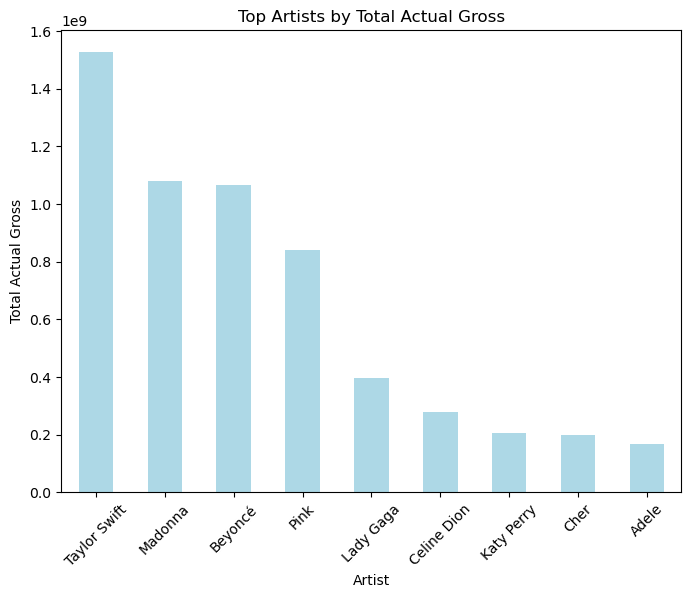

In [74]:
plt.figure(figsize=(8,6))
artist_gross.plot(kind="bar",color="lightblue")
plt.title("Top Artists by Total Actual Gross")
plt.xlabel("Artist")
plt.ylabel("Total Actual Gross")
plt.xticks(rotation=45)
plt.show()

In [76]:
plt.figure(figsize=(8,5))
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

<Figure size 800x500 with 0 Axes>

In [66]:
df.columns.to_list()

['rank',
 'peak',
 'actual_gross',
 'adjusted_gross',
 'artist',
 'tour_title',
 'years',
 'shows',
 'average_gross']

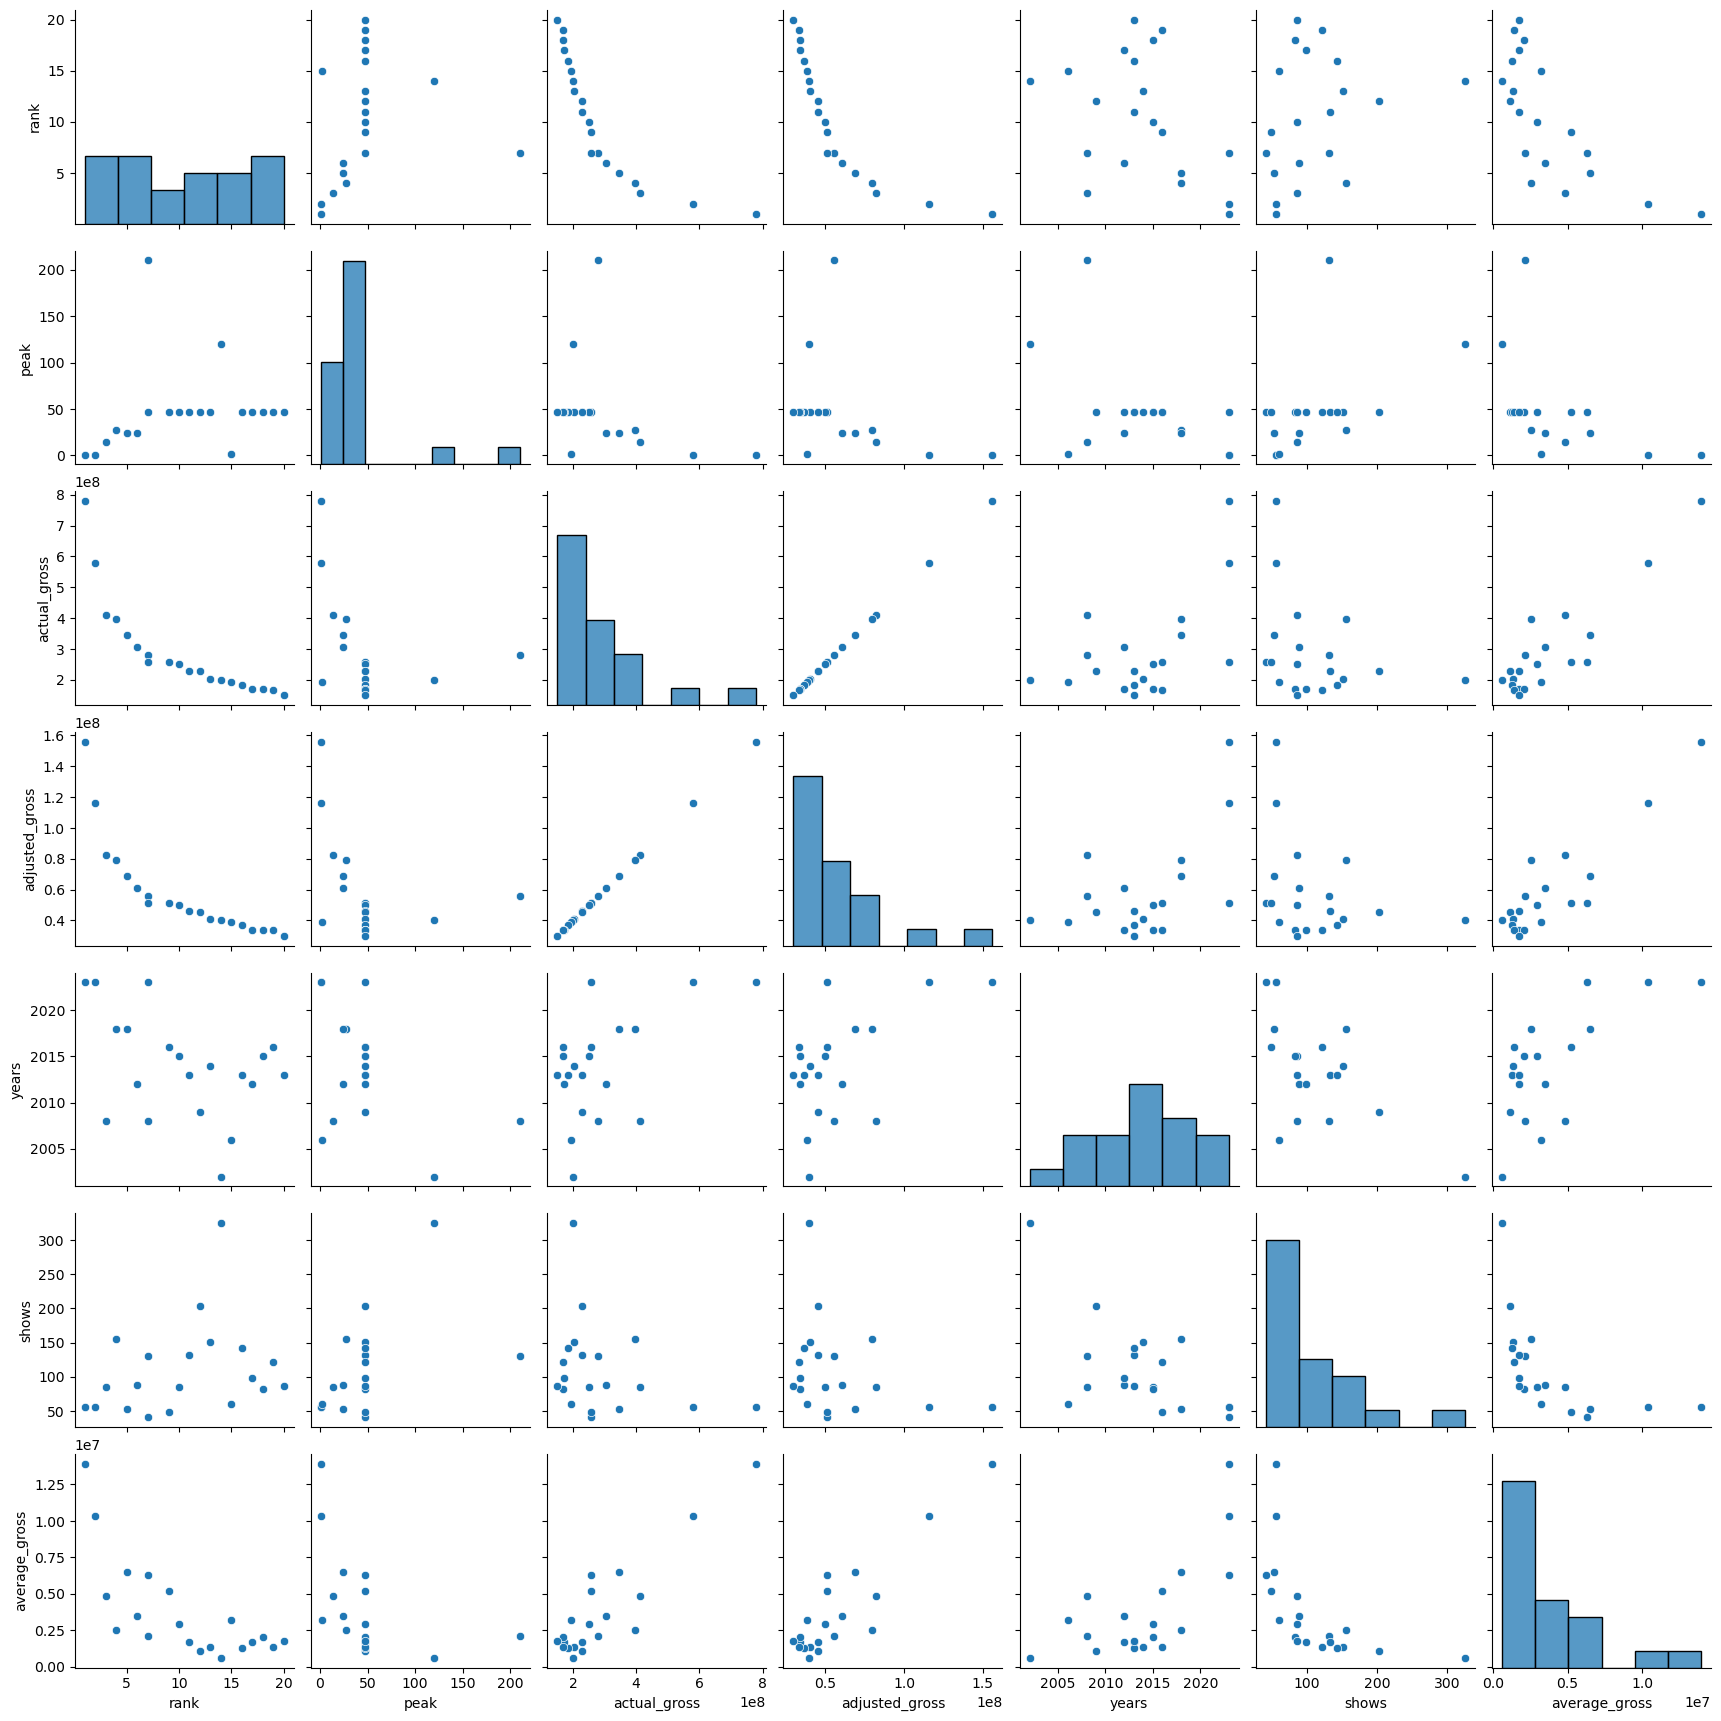

In [82]:
sns.pairplot(data=df, palette='viridis')
plt.show()

In [95]:
hist = df.groupby("artist")["actual_gross"].sum()
hist

artist
Adele            167700000
Beyoncé         1064984556
Celine Dion      280000000
Cher             200000000
Katy Perry       204000000
Lady Gaga        397400000
Madonna         1079958363
Pink             838900000
Taylor Swift    1526075146
Name: actual_gross, dtype: int64

<Axes: xlabel='artist'>

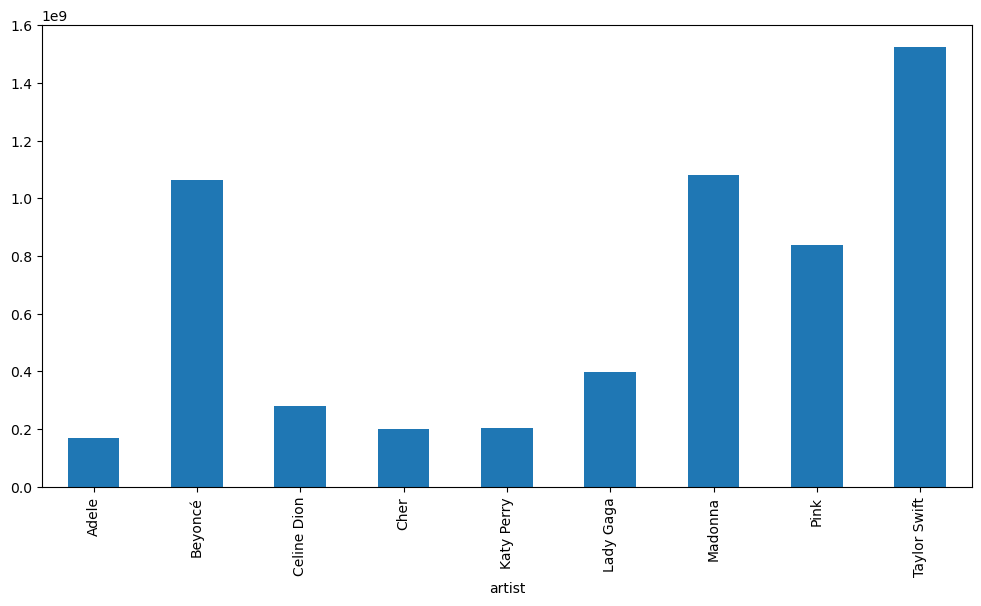

In [96]:
plt.figure(figsize=(12,6))
hist.plot(kind="bar",color="")

